# 🏎️ F1 Pit Stop Prediction ML Pipeline - Part 1: Data Loading & EDA

## 🎯 Project Objective
Build a machine learning model to **predict pit stop events** in Formula 1 racing using historical race data. This demonstrates proficiency in the complete ML lifecycle: data exploration → engineering → modeling → evaluation.

## 📚 Part 1 Goals
✅ Load and inspect datasets  
✅ Perform comprehensive EDA (Exploratory Data Analysis)  
✅ Analyze missing values and data quality  
✅ Visualize feature distributions  
✅ Understand domain-specific patterns  
✅ Identify relationships between variables  

## 🔬 Why EDA Matters
- **90% of ML success** comes from understanding data
- Identifies data quality issues before modeling
- Guides feature engineering decisions
- Uncovers domain-specific patterns
- Informs model selection and hyperparameters

## 📚 Library Imports & Configuration

In [1]:
# ============================================================
# COMPREHENSIVE LIBRARY IMPORTS
# ============================================================
# Data manipulation and numerical computing
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Gradient boosting
from xgboost import XGBRegressor

# Suppress warnings for clean output
import warnings
warnings.filterwarnings("ignore")

# Configure pandas and matplotlib for professional output
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
plt.style.use("ggplot")

print("✅ All libraries imported successfully!")
print("\n📊 Environment ready for data exploration...")

✅ All libraries imported successfully!

📊 Environment ready for data exploration...


# 📥 Step 1: Data Loading & Initial Inspection

## What We're Loading
- **train.csv**: Training data with target labels (PitNextLap)
- **test.csv**: Test data for final predictions
- **sample_submission.csv**: Expected output format template

## What We Check
- Dataset dimensions (rows × columns)
- Data types (numerical vs categorical)
- Column names and structure
- First/last rows (data sanity check)

In [2]:
print("Loading datasets from disk...\n")

# Load CSV files into pandas DataFrames
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
sample_submission = pd.read_csv("data/sample_submission.csv")

print("✅ Datasets loaded successfully!\n")
print("="*70)
print("DATASET DIMENSIONS")
print("="*70)
print(f"Training set:      {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Test set:          {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
print(f"Sample submission: {sample_submission.shape[0]:,} rows × {sample_submission.shape[1]} columns")
print("="*70)

Loading datasets from disk...



✅ Datasets loaded successfully!

DATASET DIMENSIONS
Training set:      439,140 rows × 16 columns
Test set:          188,165 rows × 15 columns
Sample submission: 188,165 rows × 2 columns


In [3]:
# Display training data preview
print("\n📊 TRAINING DATA PREVIEW\n")
print("First 5 rows:")
display(train_df.head())

print("\nData types:")
display(train_df.dtypes)

print("\nColumn names:")
print(train_df.columns.tolist())


📊 TRAINING DATA PREVIEW

First 5 rows:


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0



Data types:


id                          int64
Driver                        str
Compound                      str
Race                          str
Year                        int64
PitStop                     int64
LapNumber                   int64
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change           float64
PitNextLap                float64
dtype: object


Column names:
['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


In [4]:
# Test and sample submission preview
print("\n📊 TEST DATA PREVIEW")
print(test_df.head())

print("\n📋 SUBMISSION FORMAT TEMPLATE")
print(sample_submission.head())


📊 TEST DATA PREVIEW
       id Driver Compound                      Race  Year  PitStop  LapNumber  \
0  439140   D119   MEDIUM        British Grand Prix  2023        0         21   
1  439141    VER   MEDIUM      Abu Dhabi Grand Prix  2023        0         24   
2  439142   D270   MEDIUM        British Grand Prix  2023        0         24   
3  439143   D112     SOFT      São Paulo Grand Prix  2024        0          6   
4  439144    AND     HARD  United States Grand Prix  2024        0         52   

   Stint  TyreLife  Position  LapTime (s)  LapTime_Delta  \
0      1      21.0         4       93.387          0.280   
1      1      24.0         1       90.867         -0.129   
2      1      24.0        11       92.871          0.041   
3      2       4.0        15       94.967        -19.741   
4      2      29.0        12       99.112          0.930   

   Cumulative_Degradation  RaceProgress  Position_Change  
0                  -4.984      0.403846              0.0  
1            

# 🧩 Step 2: Missing Values Analysis

## Why This Matters
- Missing data can introduce bias in predictions
- Different handling strategies (drop, fill, predict) affect model performance
- Understanding missing patterns reveals data quality issues
- Some algorithms are more sensitive to missing values

## Analysis Approach
1. Count missing values per column
2. Calculate percentage of missing data
3. Visualize patterns with heatmap
4. Determine handling strategy

In [5]:
# Calculate missing values statistics
missing_values = train_df.isnull().sum()
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
}).sort_values(by="Missing_Percentage", ascending=False)

print("="*70)
print("MISSING VALUES SUMMARY")
print("="*70)
display(missing_df)

# Assessment
total_missing = missing_df['Missing_Count'].sum()
if total_missing == 0:
    print("\n✅ EXCELLENT: No missing values detected!")
    print("   This dataset has high quality with complete data.")
else:
    print(f"\n⚠️ WARNING: {total_missing} missing values found")


MISSING VALUES SUMMARY


,Missing_Count,Missing_Percentage
id,0,0.0
Driver,0,0.0
Compound,0,0.0
Race,0,0.0
Year,0,0.0
PitStop,0,0.0
LapNumber,0,0.0
Stint,0,0.0
TyreLife,0,0.0
Position,0,0.0



✅ EXCELLENT: No missing values detected!
   This dataset has high quality with complete data.


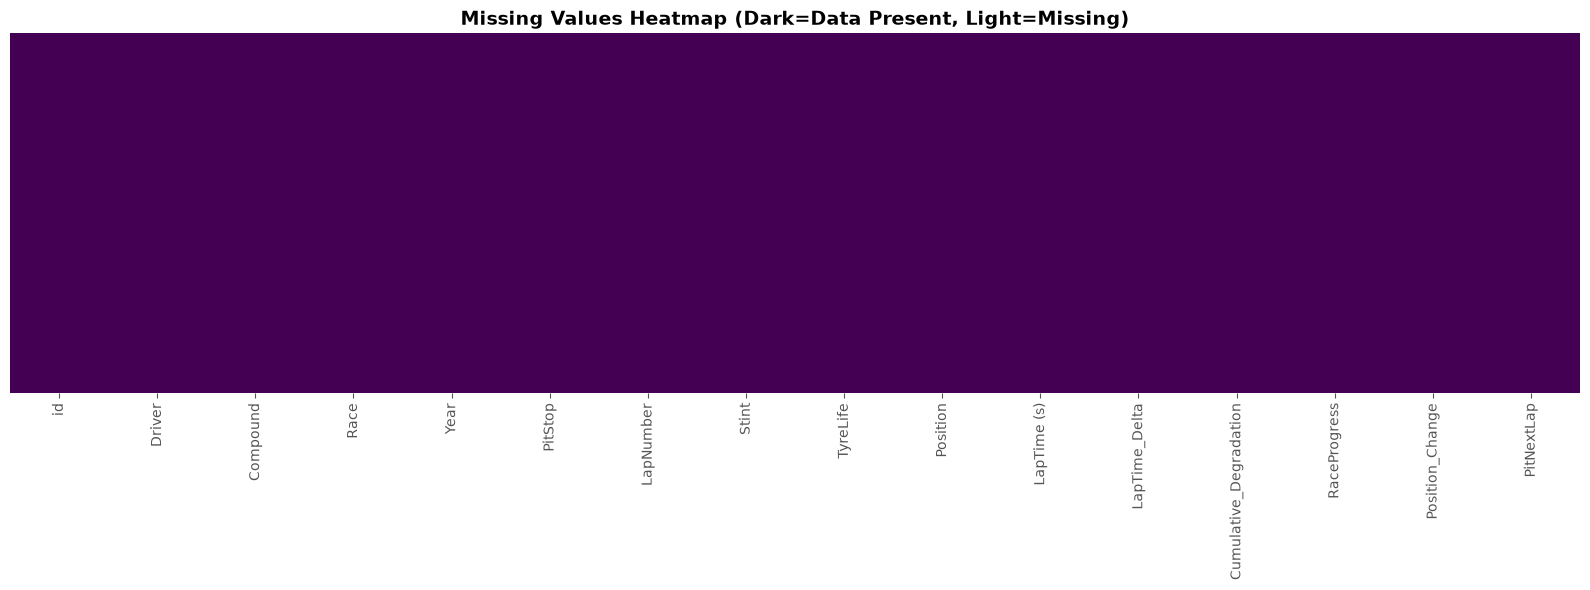

Interpretation: Each white stripe represents a missing value.


In [6]:
# Visualize missing value patterns
plt.figure(figsize=(16, 6))
sns.heatmap(
    train_df.isnull(),
    cmap="viridis",
    cbar=False,
    yticklabels=False
)
plt.title("Missing Values Heatmap (Dark=Data Present, Light=Missing)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Interpretation: Each white stripe represents a missing value.")

# 🏷️ Step 3: Feature Type Classification

## Why Separate Numerical & Categorical Features?
- **Different analysis techniques** for each type
- **Different preprocessing** requirements (scaling vs encoding)
- **Different visualization methods** (histograms vs bar charts)
- **Different algorithms** handle each type differently

In [7]:
# Identify numerical and categorical columns
numericals_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

print("="*70)
print("FEATURE CLASSIFICATION")
print("="*70)
print(f"\n🔢 Numerical Features ({len(numericals_cols)}):")
for i, col in enumerate(numericals_cols, 1):
    print(f"   {i}. {col}")

print(f"\n🏷️  Categorical Features ({len(categorical_cols)}):")
for i, col in enumerate(categorical_cols, 1):
    print(f"   {i}. {col}")

print(f"\n📊 Total Features: {len(numericals_cols) + len(categorical_cols)}")
print("="*70)

FEATURE CLASSIFICATION

🔢 Numerical Features (13):
   1. id
   2. Year
   3. PitStop
   4. LapNumber
   5. Stint
   6. TyreLife
   7. Position
   8. LapTime (s)
   9. LapTime_Delta
   10. Cumulative_Degradation
   11. RaceProgress
   12. Position_Change
   13. PitNextLap

🏷️  Categorical Features (3):
   1. Driver
   2. Compound
   3. Race

📊 Total Features: 16


# 🏎️ Step 4: Domain-Specific Analysis - Driver Performance

## F1 Context
- Different drivers have different skill levels, car setups, and pit stop strategies
- Driver consistency/variability affects predictability
- Some drivers may have more frequent or different pit stop patterns

## What We Analyze
- Lap time distribution across drivers
- Performance consistency (variance)
- Identification of fast vs slow drivers

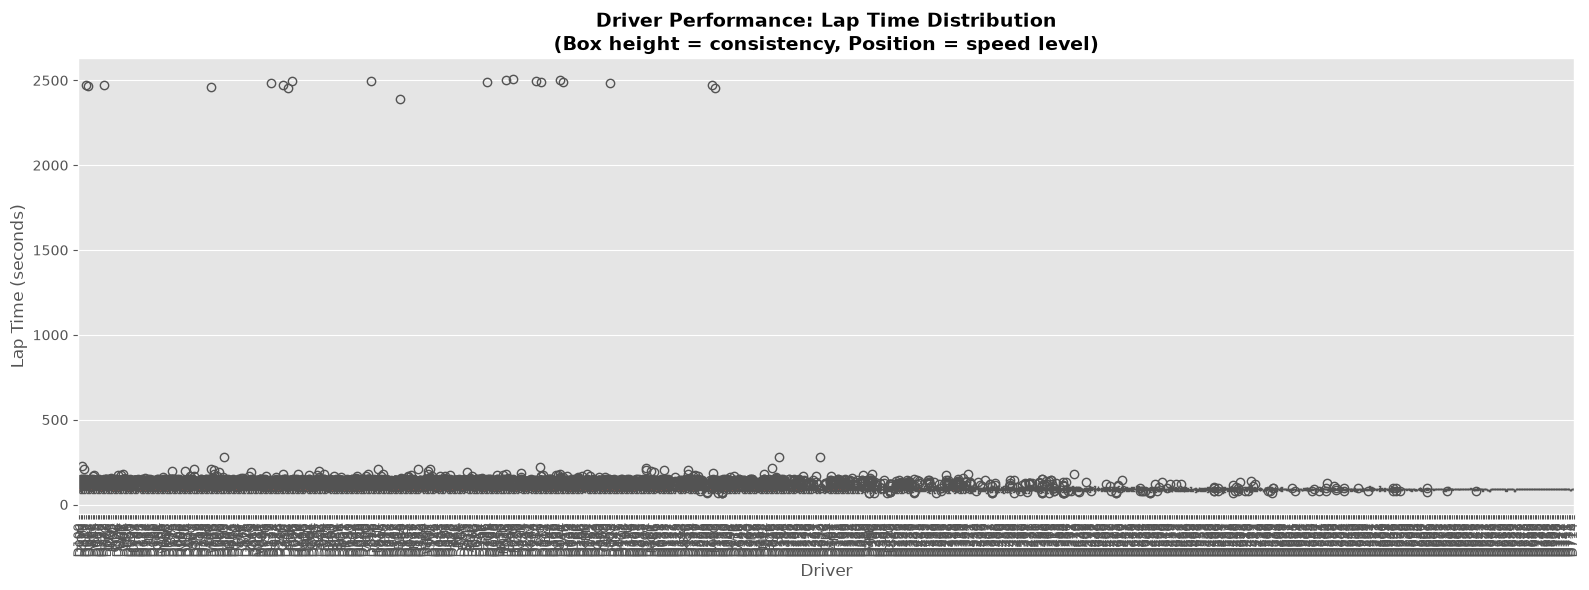

💡 Interpretation:
   - Lower position = faster drivers
   - Box height = performance variability
   - Dots = outlier lap times


In [8]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=train_df, x="Driver", y="LapTime (s)")
plt.xticks(rotation=90, fontsize=9)
plt.title("Driver Performance: Lap Time Distribution\n(Box height = consistency, Position = speed level)", 
          fontsize=14, fontweight='bold')
plt.ylabel("Lap Time (seconds)")
plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("   - Lower position = faster drivers")
print("   - Box height = performance variability")
print("   - Dots = outlier lap times")

# 🛞 Step 5: Tyre Strategy Analysis

## F1 Tyre Compounds
- **Soft**: Fastest but degrades quickly (more pit stops)
- **Medium**: Balanced performance
- **Hard**: Longer lasting, enables longer stints

## Impact on Pit Stops
- Different compounds have different degradation rates
- Affects when drivers need to pit
- Influences race strategy and pit stop frequency

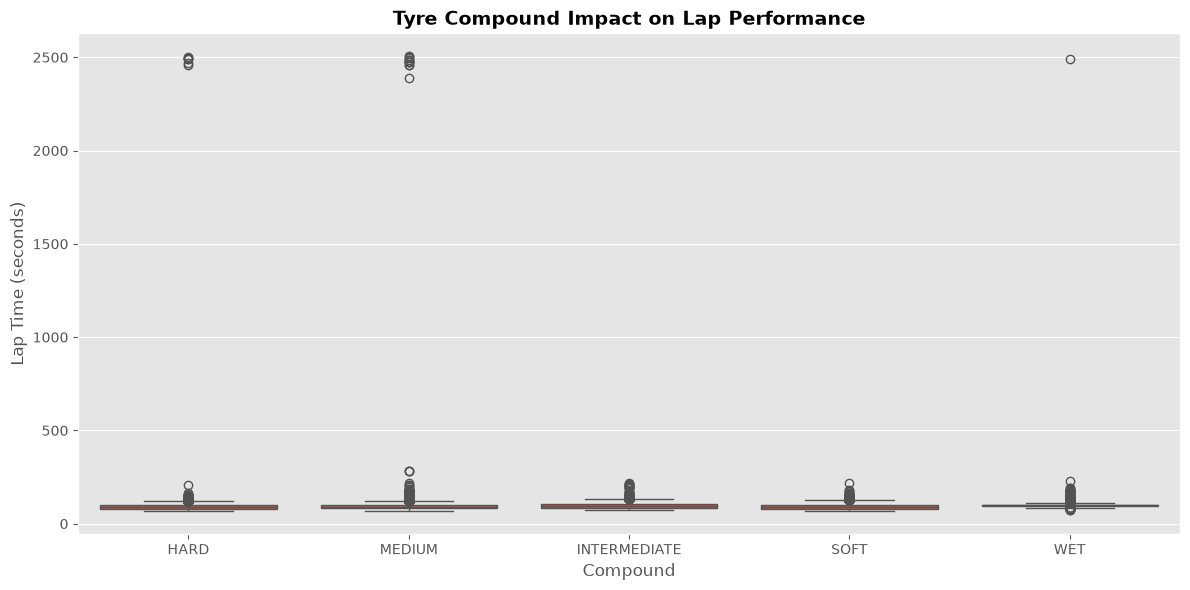

💡 Insight: Different compounds show different lap time characteristics


In [9]:
# Tyre compound analysis
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x="Compound", y="LapTime (s)")
plt.title("Tyre Compound Impact on Lap Performance", fontsize=14, fontweight='bold')
plt.ylabel("Lap Time (seconds)")
plt.tight_layout()
plt.show()
print("💡 Insight: Different compounds show different lap time characteristics")

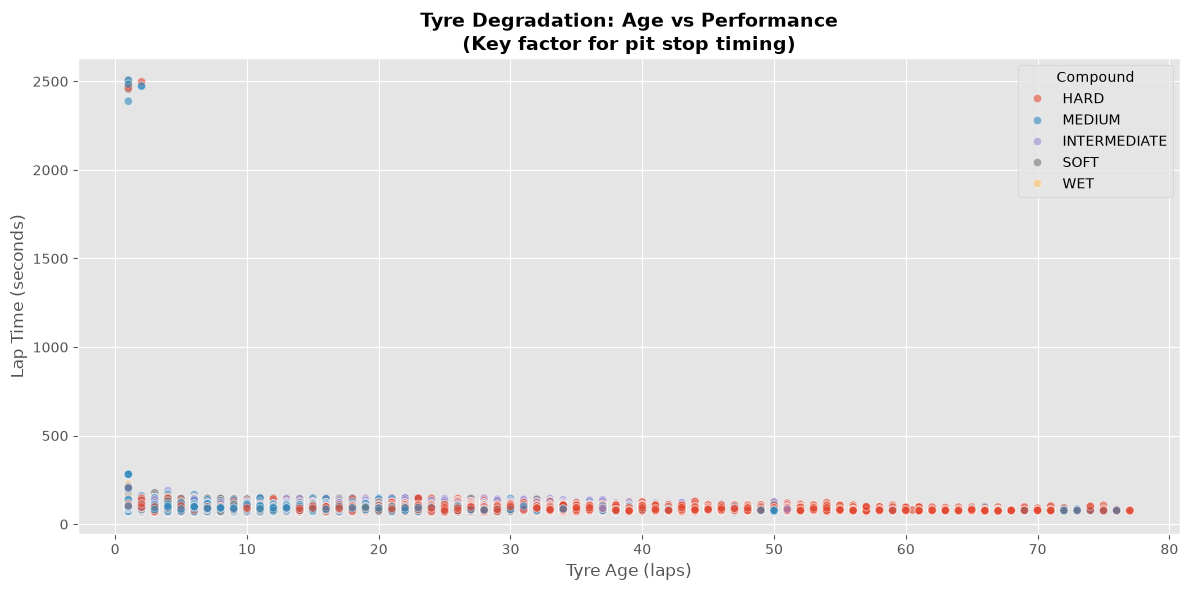

💡 Pattern: As tyres age, lap times typically increase
   This degradation triggers pit stop decisions


In [10]:
# Tyre degradation analysis
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train_df, x="TyreLife", y="LapTime (s)", hue="Compound", alpha=0.6)
plt.title("Tyre Degradation: Age vs Performance\n(Key factor for pit stop timing)", 
          fontsize=14, fontweight='bold')
plt.xlabel("Tyre Age (laps)")
plt.ylabel("Lap Time (seconds)")
plt.legend(title="Compound")
plt.tight_layout()
plt.show()
print("💡 Pattern: As tyres age, lap times typically increase")
print("   This degradation triggers pit stop decisions")

# 📍 Step 6: Race Dynamics

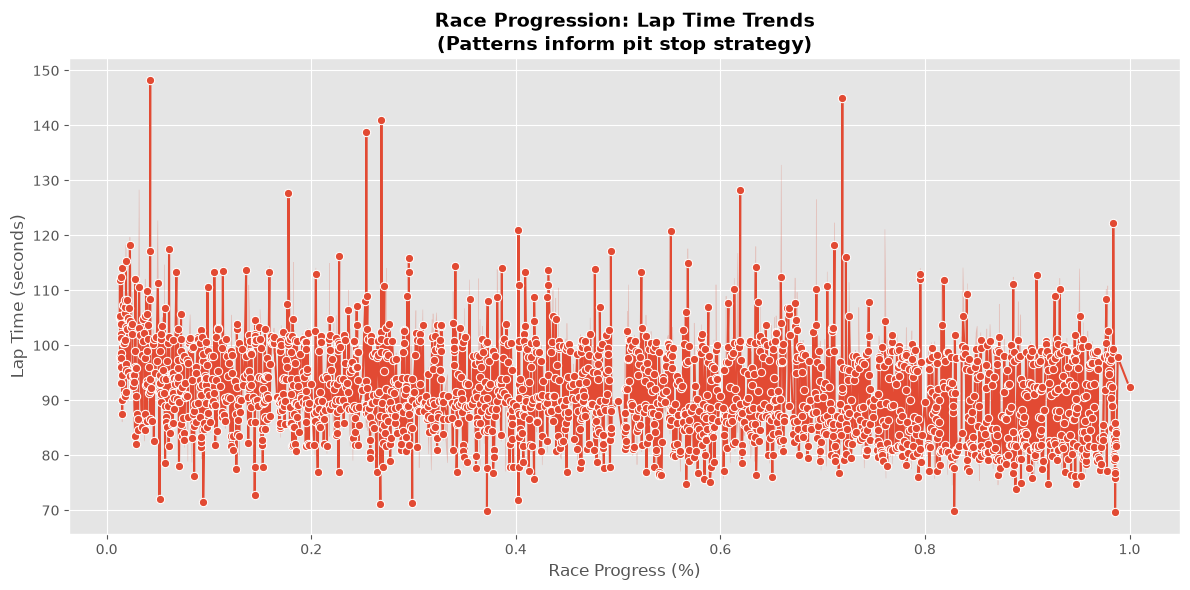

💡 Pattern interpretation:
   - Upward trend = tyre degradation
   - Downward spikes = pit stops (fresh tyres)


In [11]:
# How lap times change through the race
plt.figure(figsize=(12, 6))
sns.lineplot(data=train_df, x="RaceProgress", y="LapTime (s)", marker="o")
plt.title("Race Progression: Lap Time Trends\n(Patterns inform pit stop strategy)", 
          fontsize=14, fontweight='bold')
plt.xlabel("Race Progress (%)")
plt.ylabel("Lap Time (seconds)")
plt.tight_layout()
plt.show()
print("💡 Pattern interpretation:")
print("   - Upward trend = tyre degradation")
print("   - Downward spikes = pit stops (fresh tyres)")

# ⛽ Step 7: Target Variable Analysis

## Understanding PitNextLap
- **0**: No pit stop on next lap
- **1**: Pit stop will occur on next lap

## Importance
- **Class balance**: Affects model training and evaluation
- **Baseline**: Informs minimum acceptable performance
- **Imbalance strategy**: Determines if special handling needed

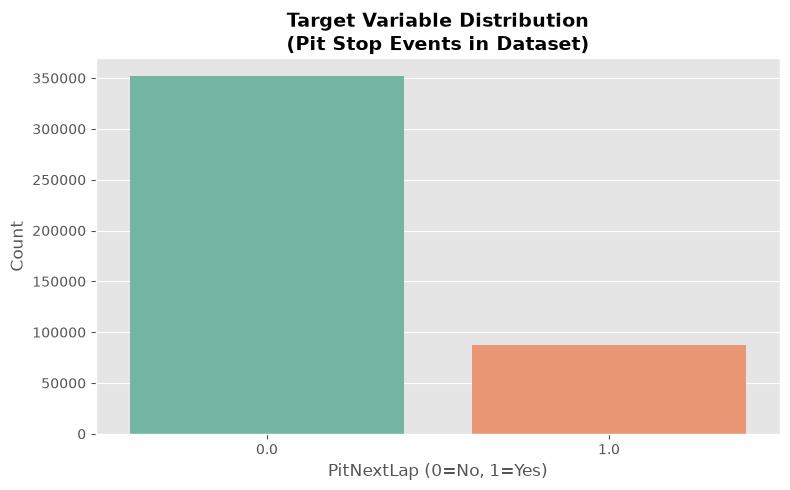


TARGET VARIABLE STATISTICS

Value Counts:
PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

Percentages:
PitNextLap
0.0    80.10179
1.0    19.89821
Name: proportion, dtype: float64

Class Balance Ratio: 24.84%


In [12]:
# Target variable distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="PitNextLap", palette="Set2")
plt.title("Target Variable Distribution\n(Pit Stop Events in Dataset)", 
          fontsize=14, fontweight='bold')
plt.xlabel("PitNextLap (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Statistics
print("\n" + "="*70)
print("TARGET VARIABLE STATISTICS")
print("="*70)
print("\nValue Counts:")
print(train_df["PitNextLap"].value_counts())
print("\nPercentages:")
print(train_df["PitNextLap"].value_counts(normalize=True) * 100)

class_counts = train_df["PitNextLap"].value_counts()
balance_ratio = class_counts[1] / class_counts[0]
print(f"\nClass Balance Ratio: {balance_ratio:.2%}")
print("="*70)

# 🔗 Step 8: Correlation Analysis

## What Correlation Tells Us
- Which features are related to our target (pit stops)
- Which features are related to each other (multicollinearity)
- Strength of relationships (-1 to 1)

## Interpretation
- **+1**: Perfect positive correlation (both increase together)
- **0**: No relationship
- **-1**: Perfect negative correlation (inverse relationship)

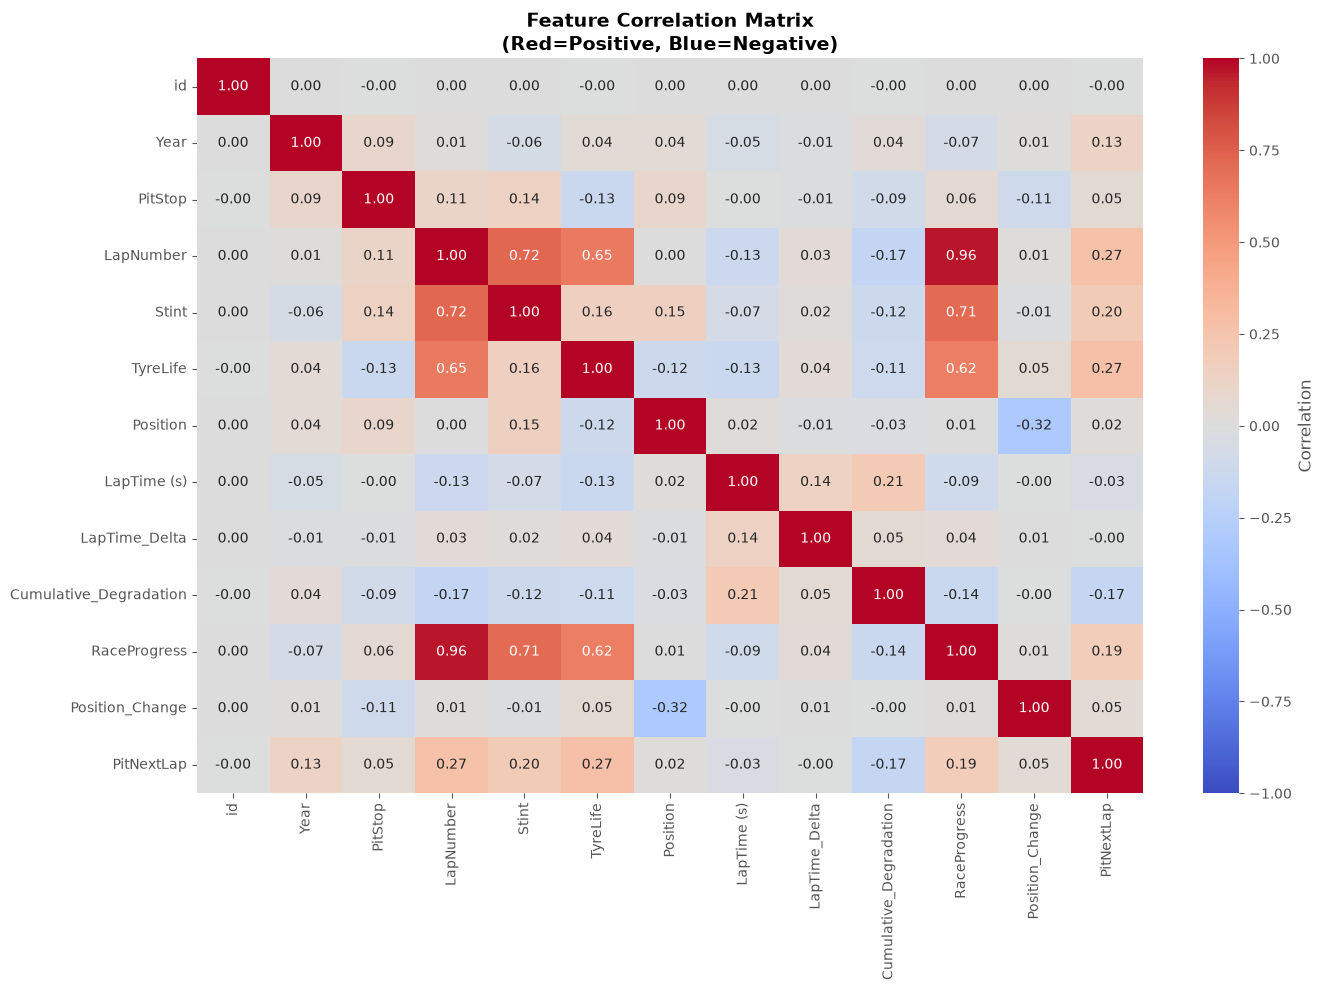

💡 Color interpretation:
   - Dark Red (1.0) = Strong positive correlation
   - Dark Blue (-1.0) = Strong negative correlation


In [13]:
# Calculate correlation matrix
correlation_matrix = train_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    cbar_kws={"label": "Correlation"}
)
plt.title("Feature Correlation Matrix\n(Red=Positive, Blue=Negative)", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Color interpretation:")
print("   - Dark Red (1.0) = Strong positive correlation")
print("   - Dark Blue (-1.0) = Strong negative correlation")

# 📈 Step 9: Detailed Numerical Feature Analysis

## For Each Numerical Feature We Calculate:
1. **Descriptive Statistics** (mean, std, min, max, quartiles)
2. **Histogram + KDE**: Shows distribution shape
3. **Boxplot**: Shows quartiles and outliers
4. **Violin Plot**: Shows probability density
5. **Skewness**: Measures asymmetry of distribution

## Why This Matters
- Identifies features needing transformation (scaling, normalization)
- Detects outliers that might need special handling
- Guides feature engineering decisions
- Informs model selection (some models sensitive to skewed data)


ANALYZING: id

Statistics:
count    439140.000000
mean     219569.500000
std      126768.942943
min           0.000000
25%      109784.750000
50%      219569.500000
75%      329354.250000
max      439139.000000
Name: id, dtype: float64


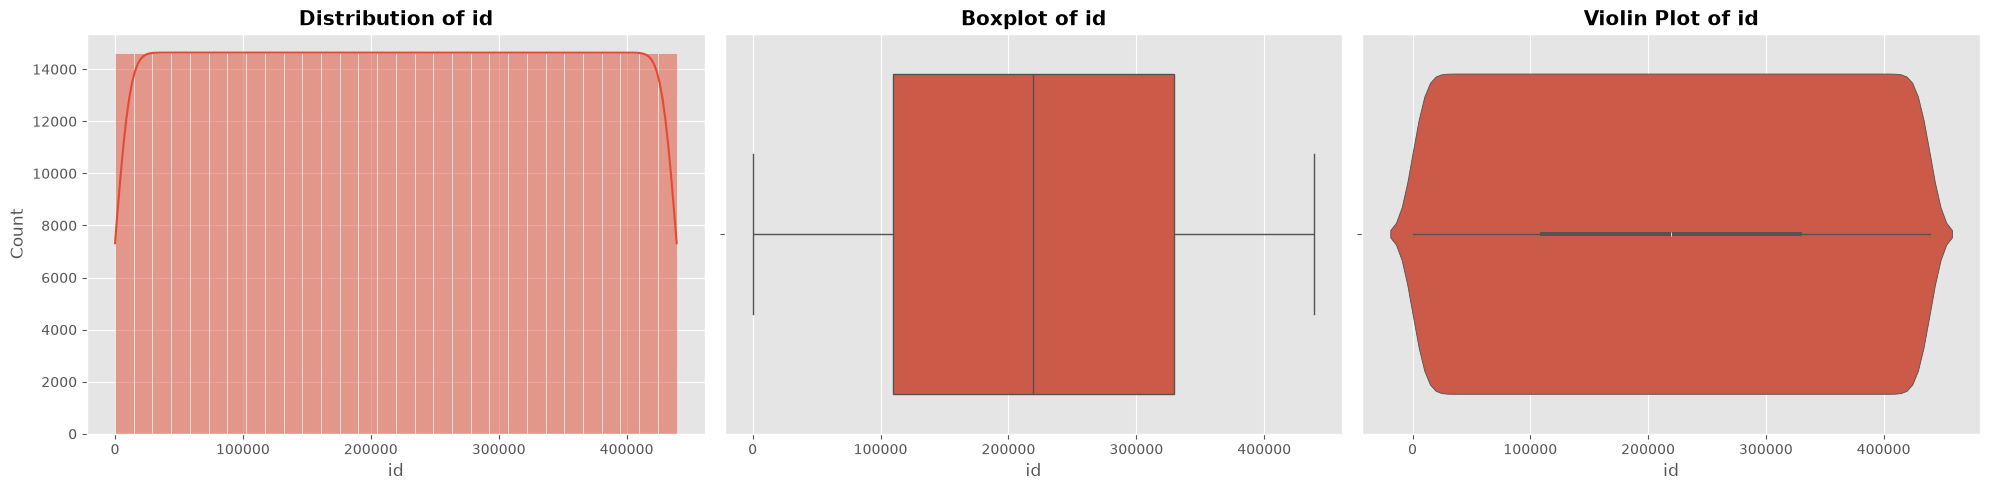


Skewness: 0.0000
   → Fairly symmetrical distribution

ANALYZING: Year

Statistics:
count    439140.000000
mean       2023.523544
std           1.024930
min        2022.000000
25%        2023.000000
50%        2024.000000
75%        2024.000000
max        2025.000000
Name: Year, dtype: float64


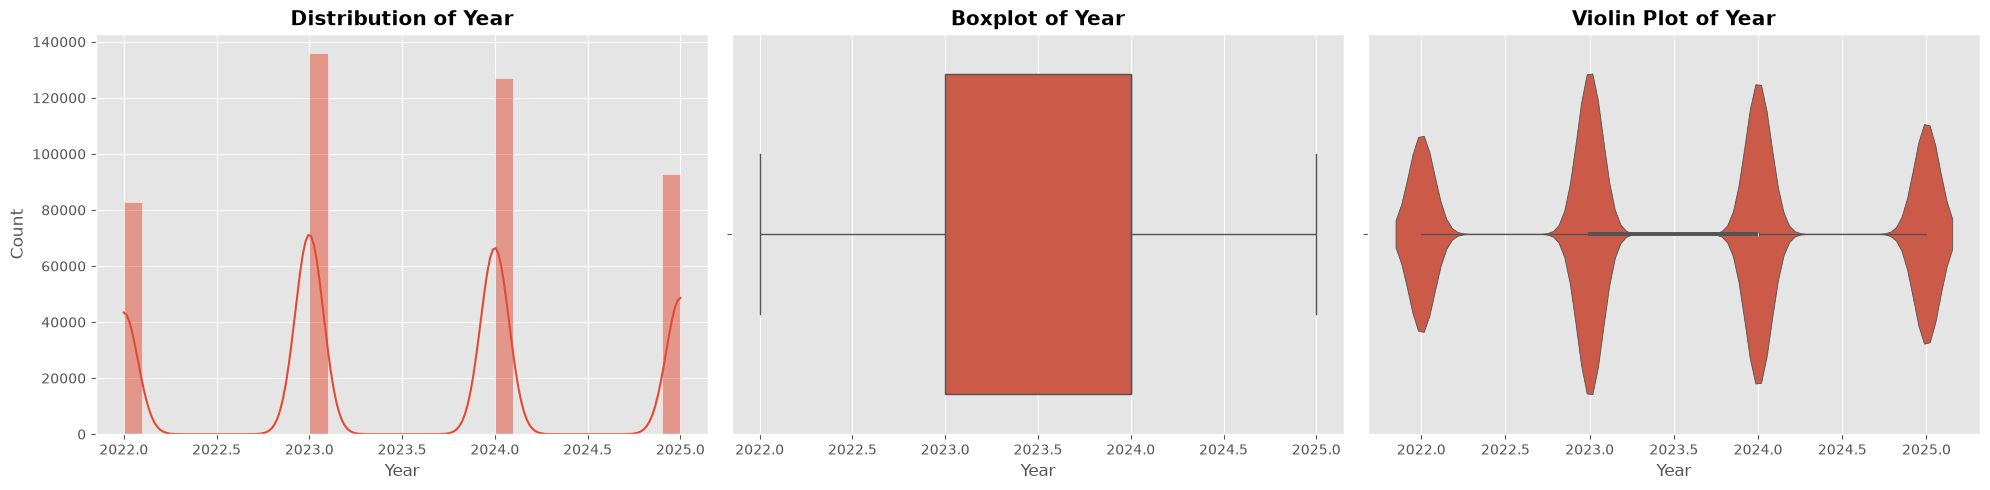


Skewness: -0.0006
   → Fairly symmetrical distribution

ANALYZING: PitStop

Statistics:
count    439140.000000
mean          0.136118
std           0.342915
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: PitStop, dtype: float64


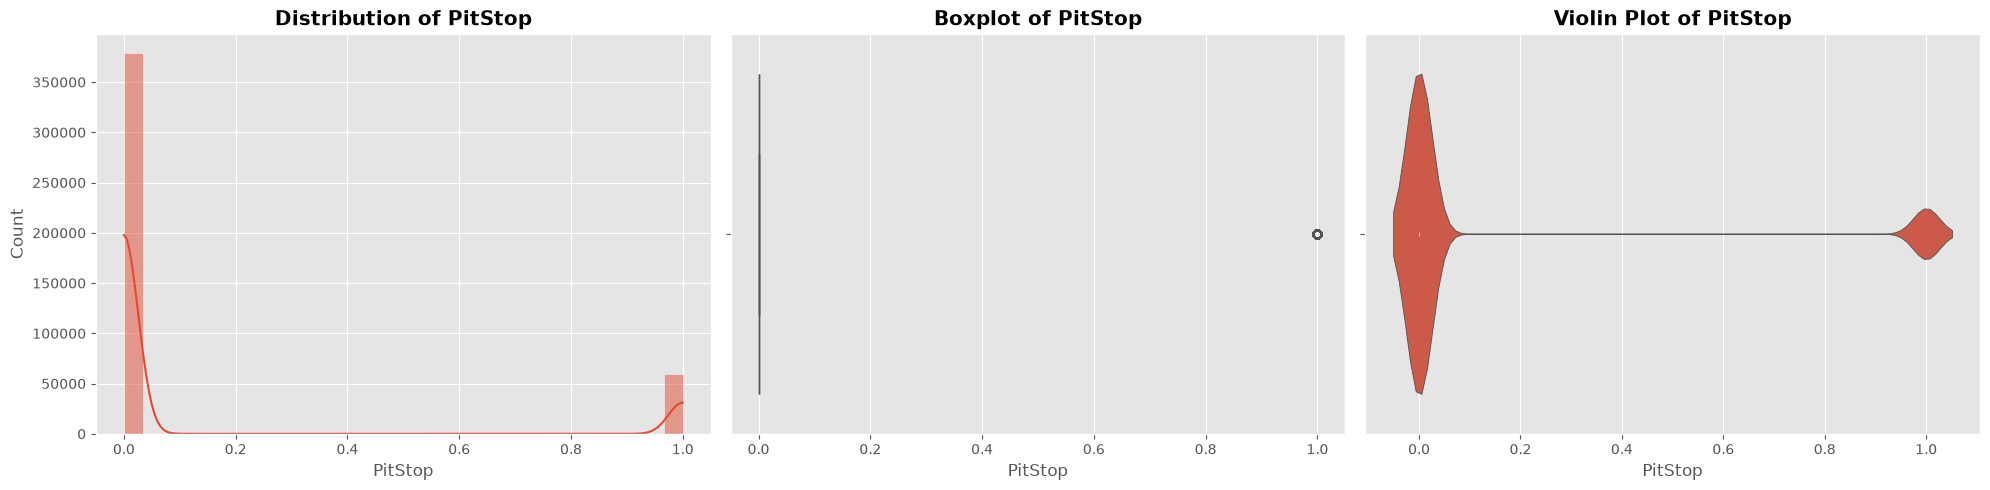


Skewness: 2.1223
   → Right-skewed (tail on right side)

ANALYZING: LapNumber

Statistics:
count    439140.000000
mean         23.105909
std          16.958261
min           1.000000
25%           9.000000
50%          19.000000
75%          36.000000
max          78.000000
Name: LapNumber, dtype: float64


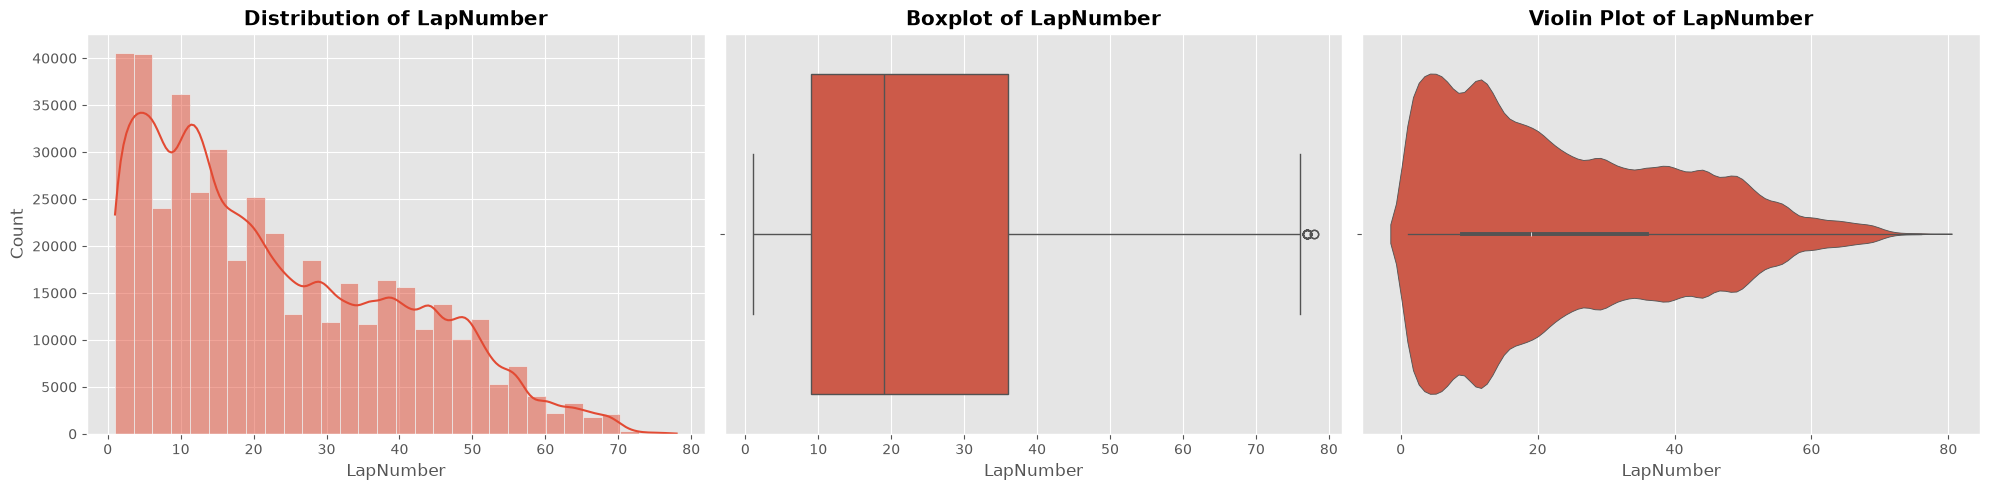


Skewness: 0.6460
   → Right-skewed (tail on right side)

ANALYZING: Stint

Statistics:
count    439140.000000
mean          1.789113
std           0.950194
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           8.000000
Name: Stint, dtype: float64


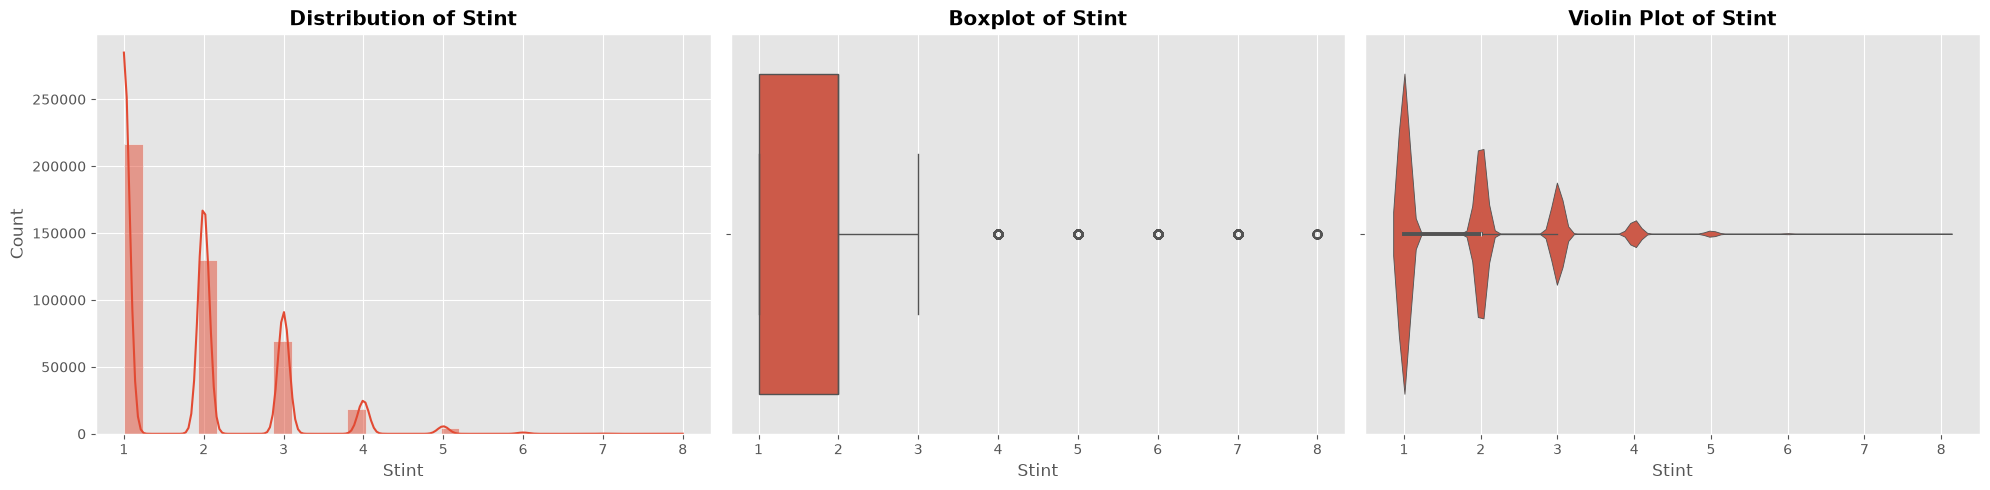


Skewness: 1.1855
   → Right-skewed (tail on right side)

ANALYZING: TyreLife

Statistics:
count    439140.000000
mean         14.158231
std           9.801338
min           1.000000
25%           6.000000
50%          12.000000
75%          20.000000
max          77.000000
Name: TyreLife, dtype: float64


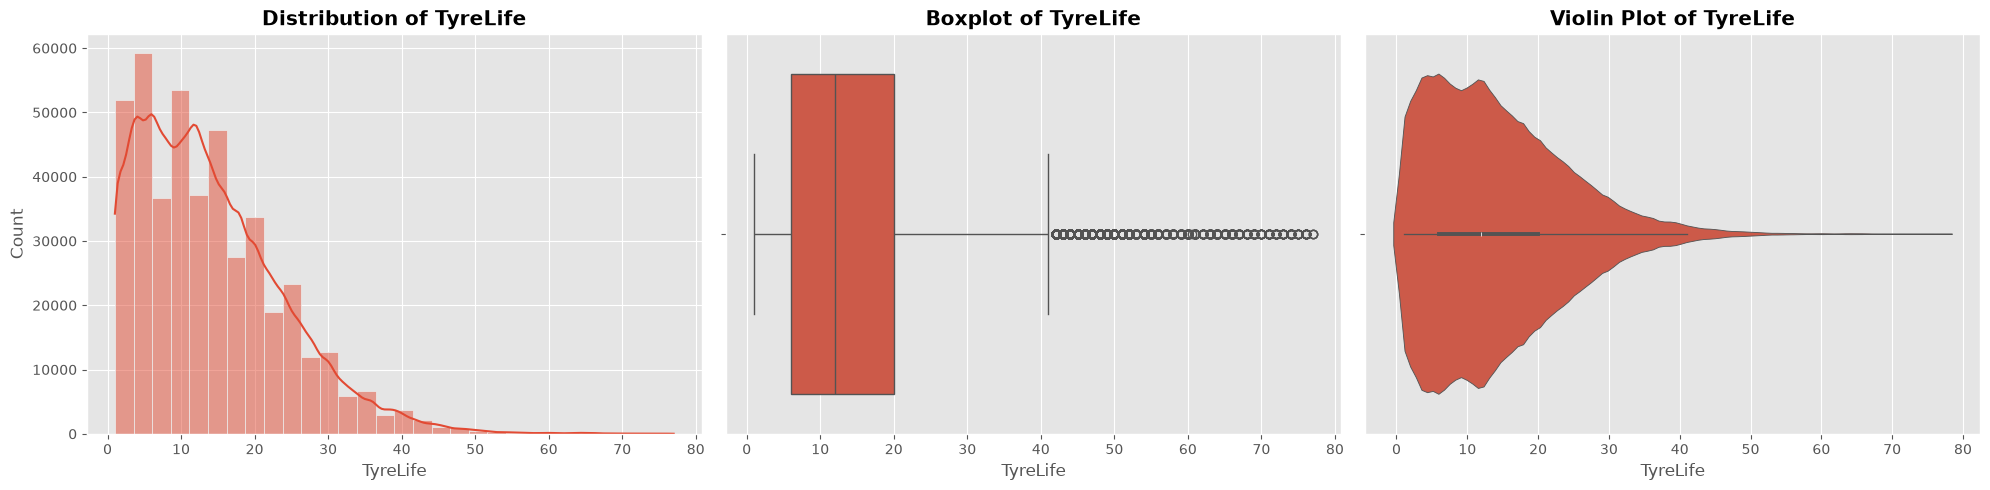


Skewness: 1.0324
   → Right-skewed (tail on right side)

ANALYZING: Position

Statistics:
count    439140.000000
mean          9.630339
std           5.278770
min           1.000000
25%           5.000000
50%          10.000000
75%          14.000000
max          20.000000
Name: Position, dtype: float64


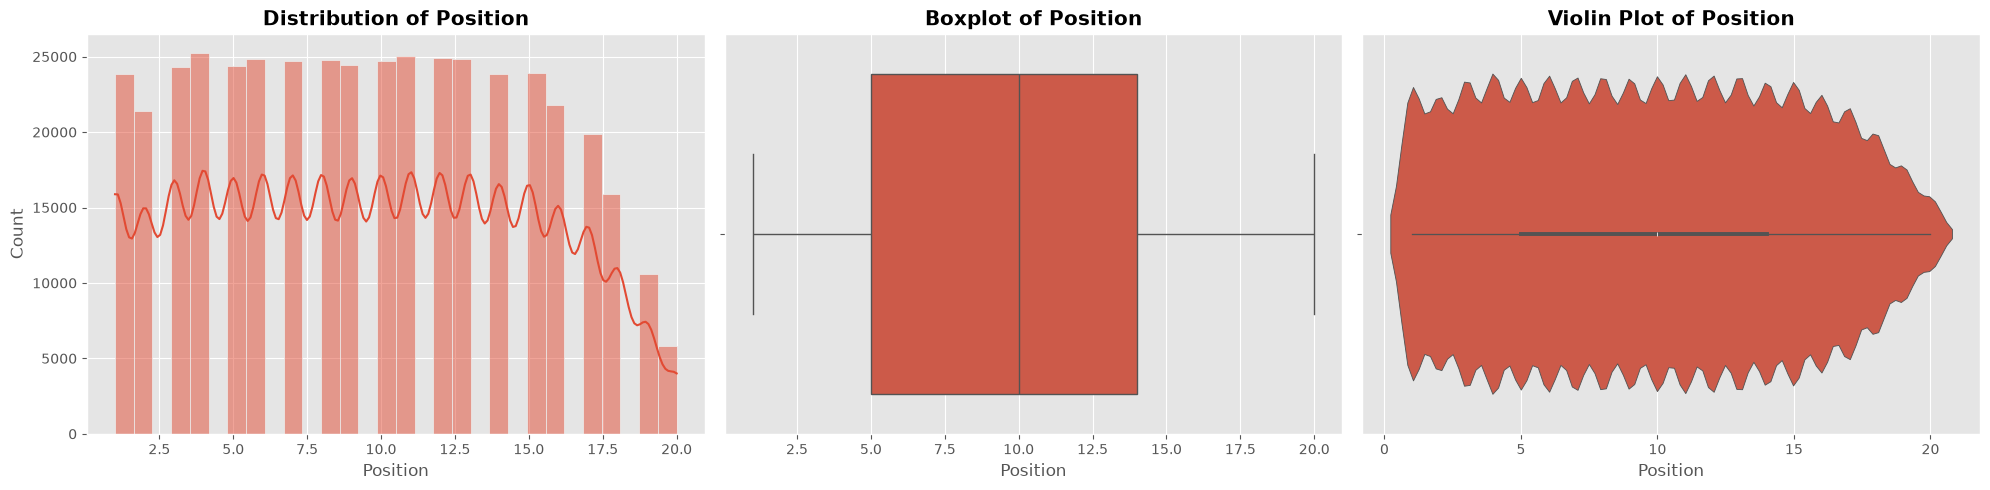


Skewness: 0.0701
   → Fairly symmetrical distribution

ANALYZING: LapTime (s)

Statistics:
count    439140.000000
mean         90.948735
std          19.772769
min          67.694000
25%          82.621000
50%          90.521000
75%          98.471000
max        2507.607000
Name: LapTime (s), dtype: float64


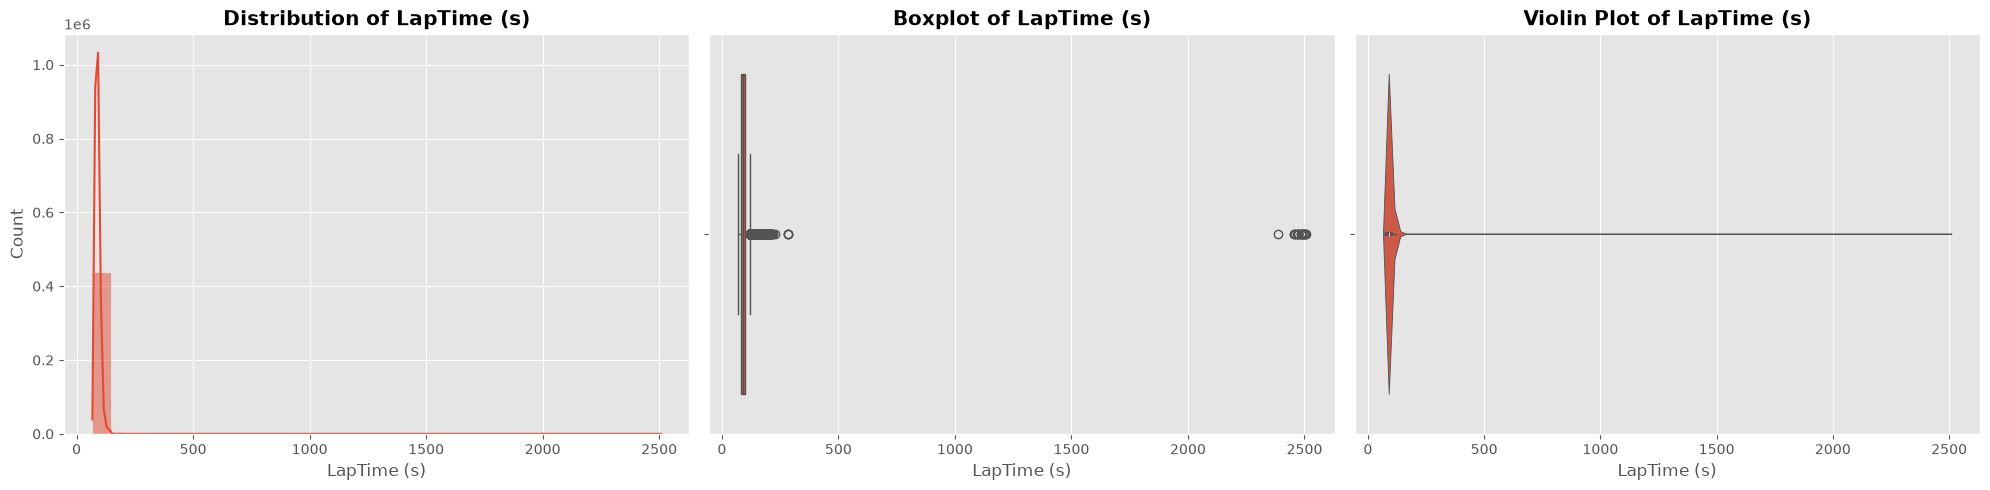


Skewness: 80.3343
   → Right-skewed (tail on right side)

ANALYZING: LapTime_Delta

Statistics:
count    439140.000000
mean         -3.770040
std          43.945759
min       -2403.895000
25%          -8.884000
50%          -0.295000
75%           0.115000
max        2423.932000
Name: LapTime_Delta, dtype: float64


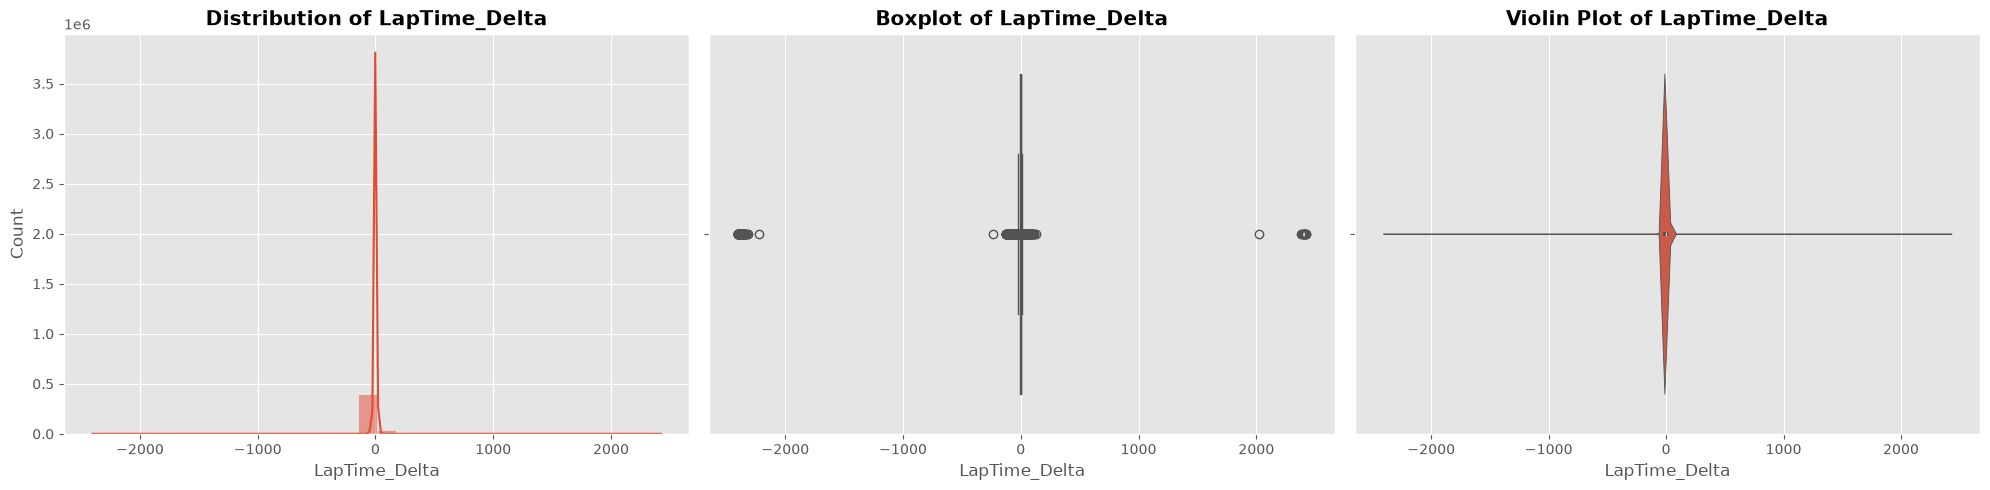


Skewness: -40.8551
   → Left-skewed (tail on left side)

ANALYZING: Cumulative_Degradation

Statistics:
count    439140.000000
mean        -25.721759
std          54.766573
min        -274.564000
25%         -46.566250
50%         -20.994000
75%          -6.199000
max        2412.026000
Name: Cumulative_Degradation, dtype: float64


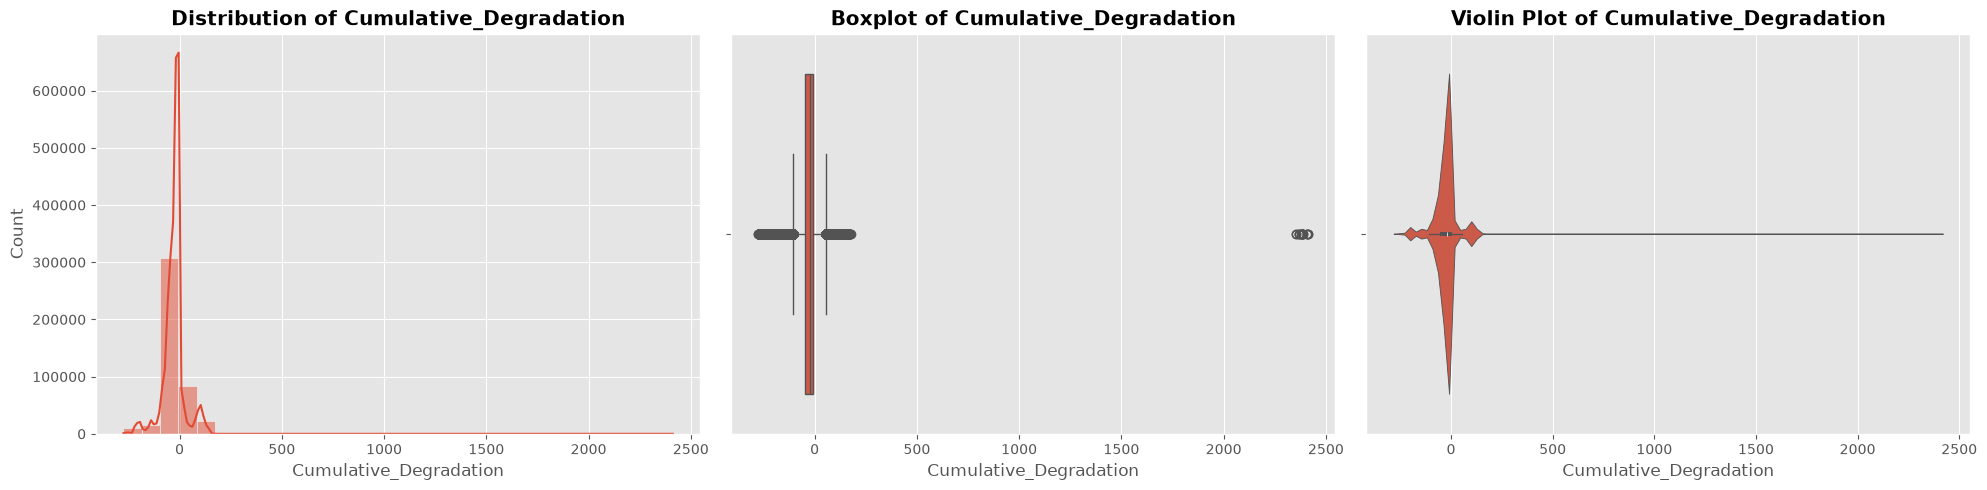


Skewness: 3.1915
   → Right-skewed (tail on right side)

ANALYZING: RaceProgress

Statistics:
count    439140.000000
mean          0.337661
std           0.253277
min           0.012821
25%           0.129870
50%           0.269231
75%           0.513158
max           1.000000
Name: RaceProgress, dtype: float64


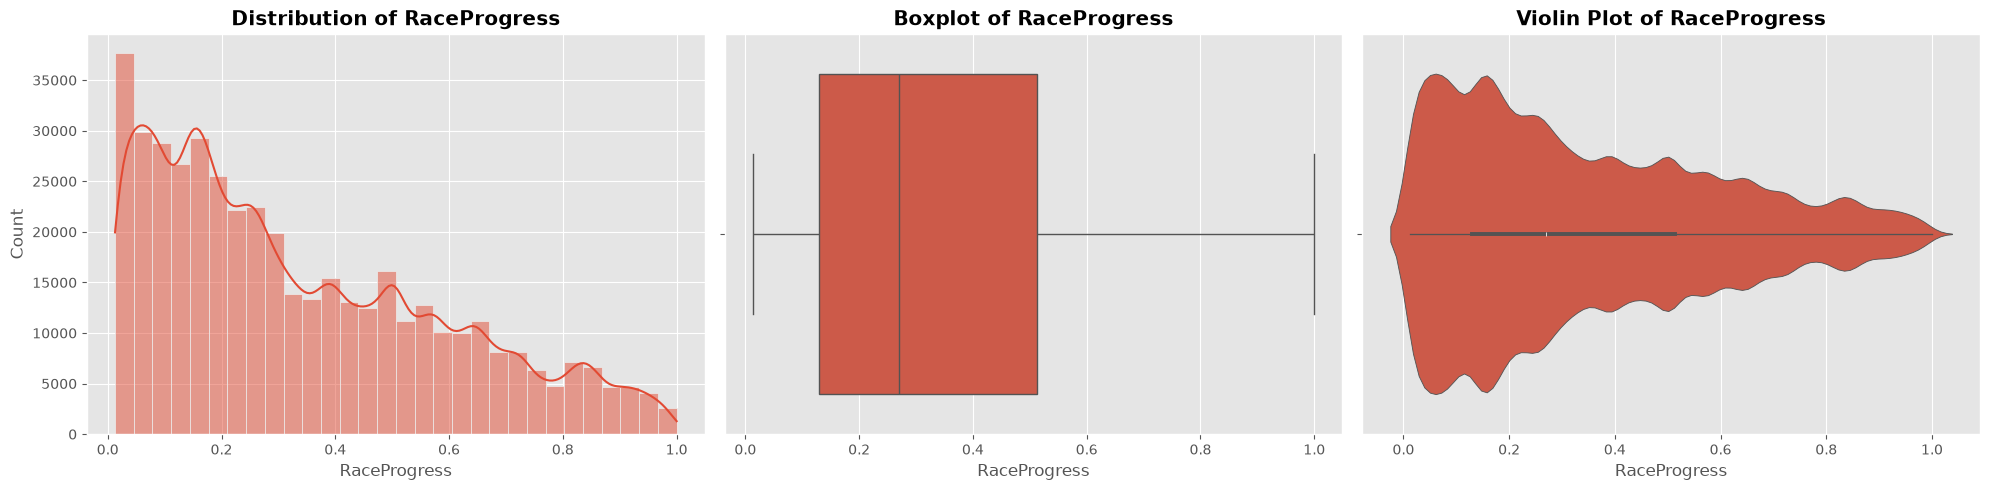


Skewness: 0.7000
   → Right-skewed (tail on right side)

ANALYZING: Position_Change

Statistics:
count    439140.000000
mean          0.101542
std           4.006765
min         -18.000000
25%          -1.000000
50%           0.000000
75%           2.000000
max          18.000000
Name: Position_Change, dtype: float64


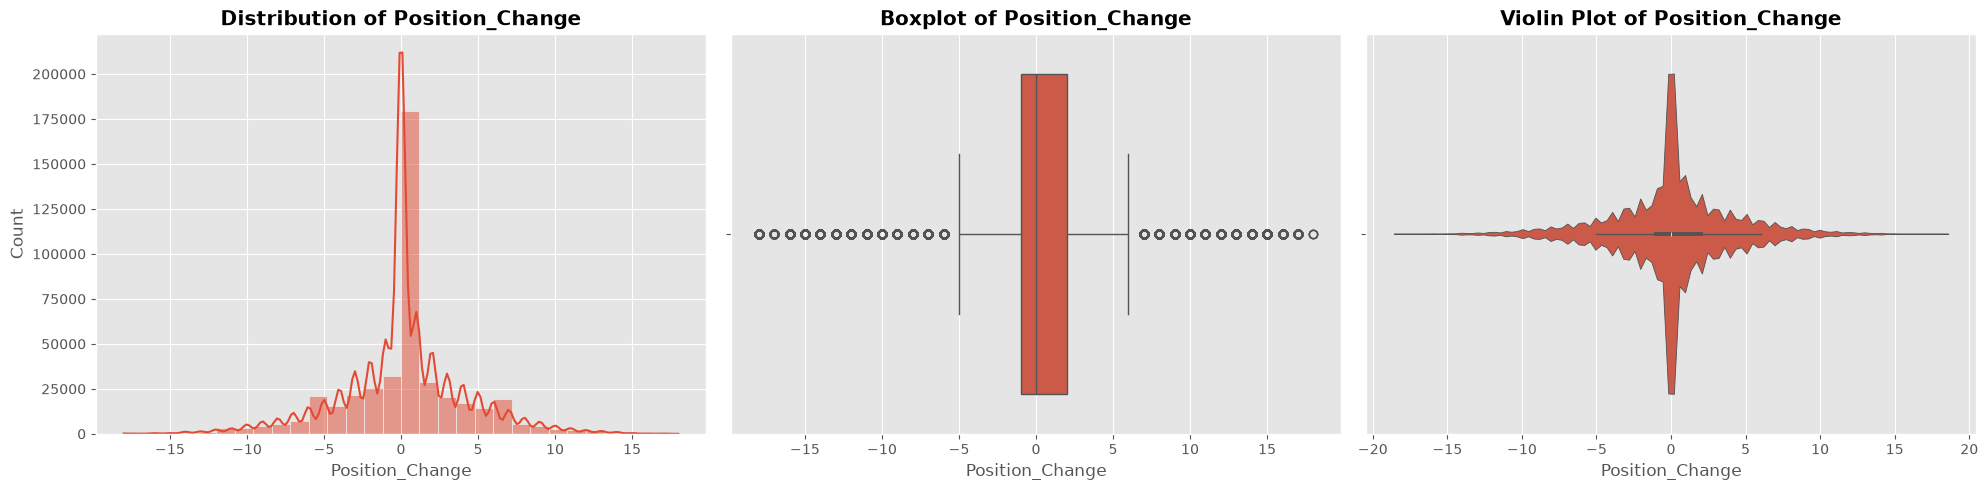


Skewness: -0.0927
   → Fairly symmetrical distribution

ANALYZING: PitNextLap

Statistics:
count    439140.000000
mean          0.198982
std           0.399235
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: PitNextLap, dtype: float64


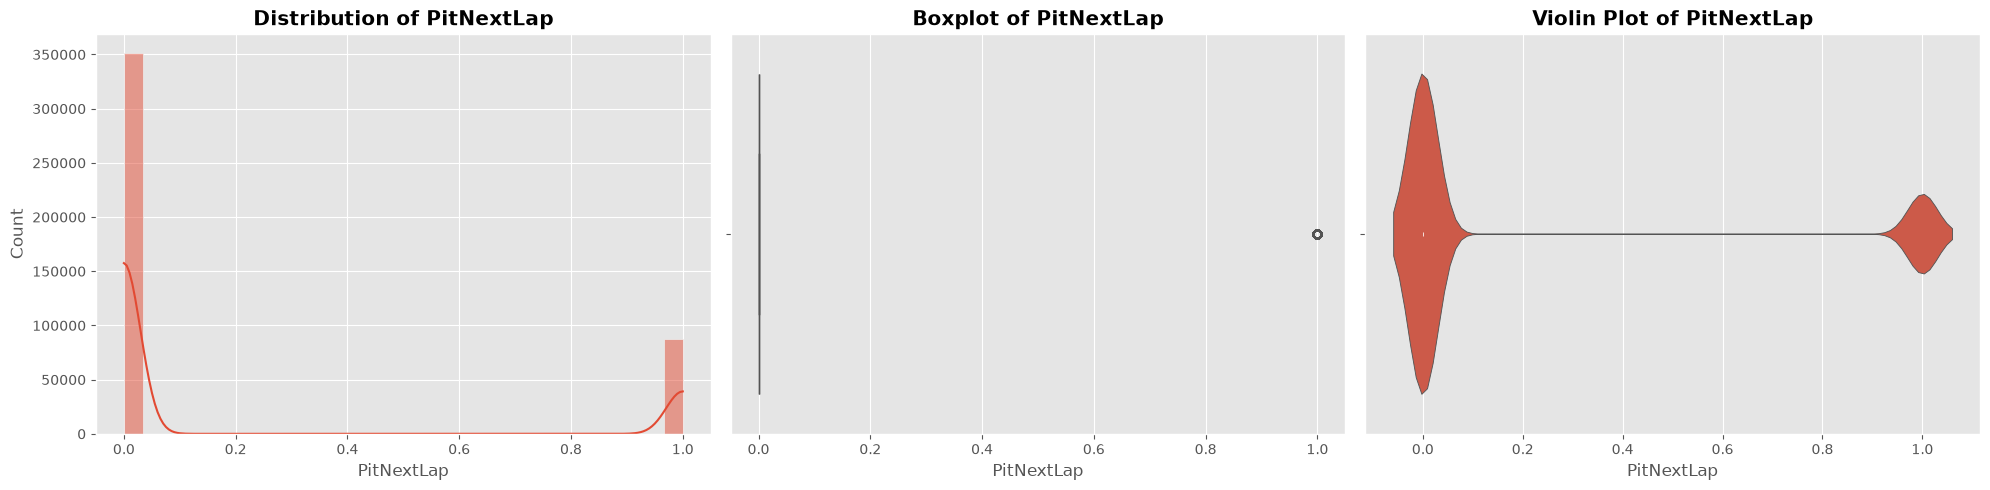


Skewness: 1.5080
   → Right-skewed (tail on right side)


In [14]:
# Comprehensive numerical feature analysis
for col in numericals_cols:
    print("\n" + "="*80)
    print(f"ANALYZING: {col}")
    print("="*80)
    
    print("\nStatistics:")
    print(train_df[col].describe())
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Histogram with KDE
    sns.histplot(train_df[col], kde=True, ax=axes[0], bins=30)
    axes[0].set_title(f"Distribution of {col}", fontweight='bold')
    
    # Boxplot
    sns.boxplot(x=train_df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}", fontweight='bold')
    
    # Violin plot
    sns.violinplot(x=train_df[col], ax=axes[2])
    axes[2].set_title(f"Violin Plot of {col}", fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Skewness analysis
    skewness = train_df[col].skew()
    print(f"\nSkewness: {skewness:.4f}")
    if abs(skewness) < 0.5:
        print("   → Fairly symmetrical distribution")
    elif skewness > 0:
        print("   → Right-skewed (tail on right side)")
    else:
        print("   → Left-skewed (tail on left side)")

# 🏷️ Step 10: Categorical Feature Analysis

## For Each Categorical Feature We:
1. Count unique values and their frequencies
2. Create bar charts showing distributions
3. Identify dominant categories
4. Assess balance across categories

## Domain Importance
- **Driver**: May have strong influence on pit stop patterns
- **Compound**: Different degradation rates affect pit timing
- **Race**: Different races may have different strategies


ANALYZING: Driver

Unique values: 887

Value distribution:
Driver
MAS     1682
RAI     1669
BAR     1656
BUT     1655
FIS     1651
        ... 
D711       1
D755       1
D731       1
D716       1
D714       1
Name: count, Length: 887, dtype: int64


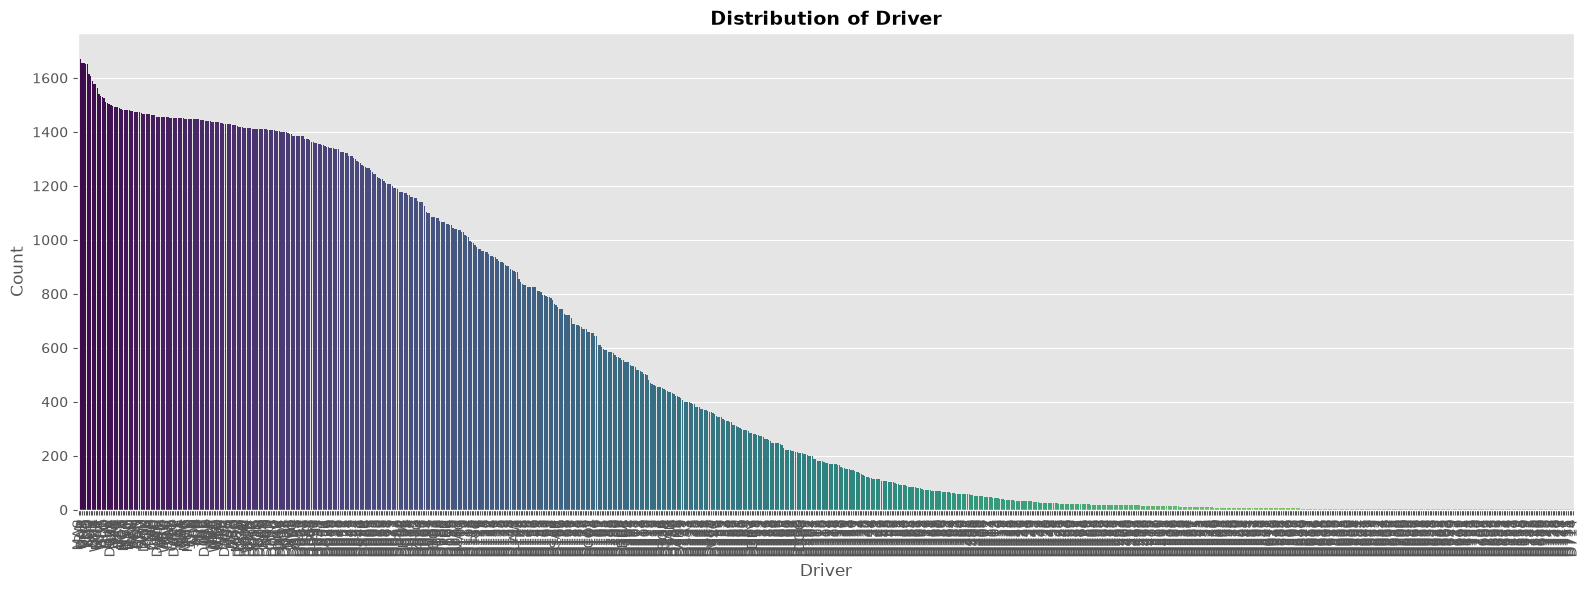


Most common: MAS (0.4% of data)

ANALYZING: Compound

Unique values: 5

Value distribution:
Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64


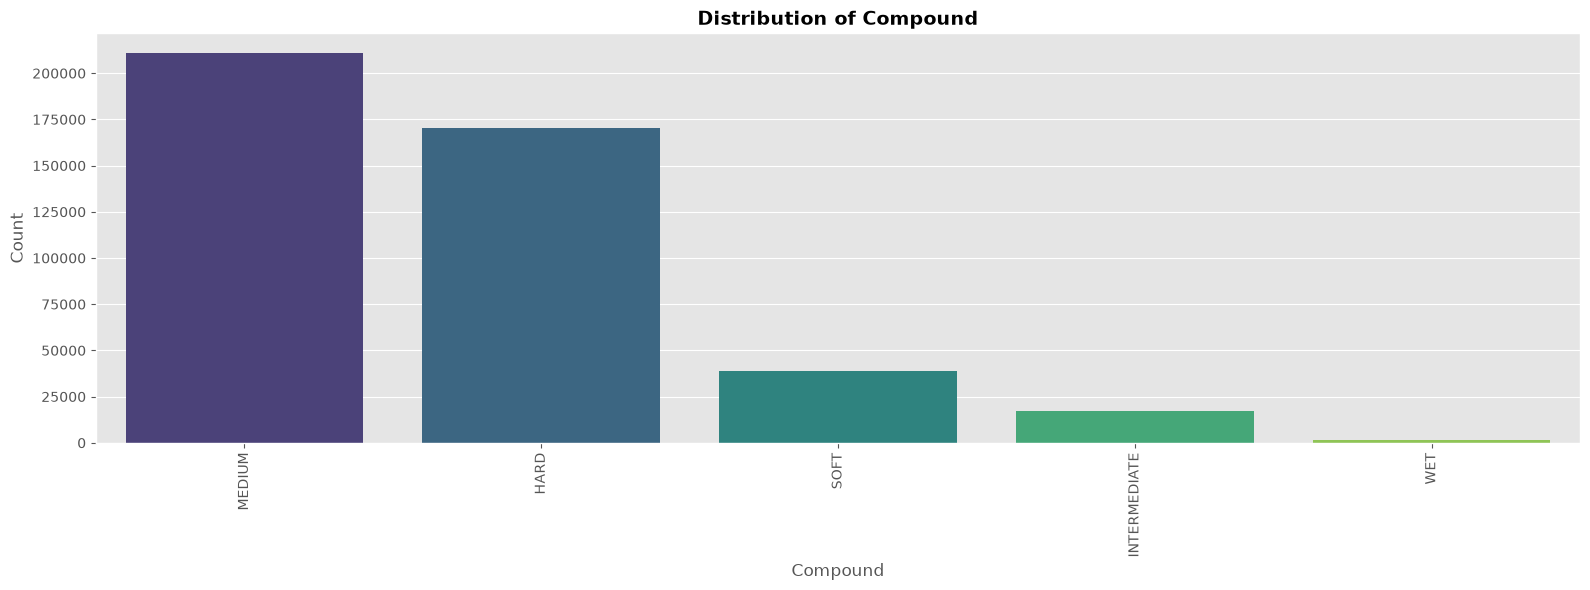


Most common: MEDIUM (48.1% of data)

ANALYZING: Race

Unique values: 26

Value distribution:
Race
Dutch Grand Prix             24462
Mexico City Grand Prix       23672
Pre-Season Testing           22492
Hungarian Grand Prix         22481
Monaco Grand Prix            21539
Canadian Grand Prix          21416
Austrian Grand Prix          21223
Spanish Grand Prix           20483
Italian Grand Prix           19854
Bahrain Grand Prix           19535
Singapore Grand Prix         18960
Miami Grand Prix             18860
Australian Grand Prix        18406
Saudi Arabian Grand Prix     18111
United States Grand Prix     18045
Abu Dhabi Grand Prix         16427
Emilia Romagna Grand Prix    15483
British Grand Prix           15383
Qatar Grand Prix             13817
Japanese Grand Prix          12891
Las Vegas Grand Prix         12479
Azerbaijan Grand Prix        12126
São Paulo Grand Prix         11497
Belgian Grand Prix            9002
Chinese Grand Prix            7311
French Grand Prix         

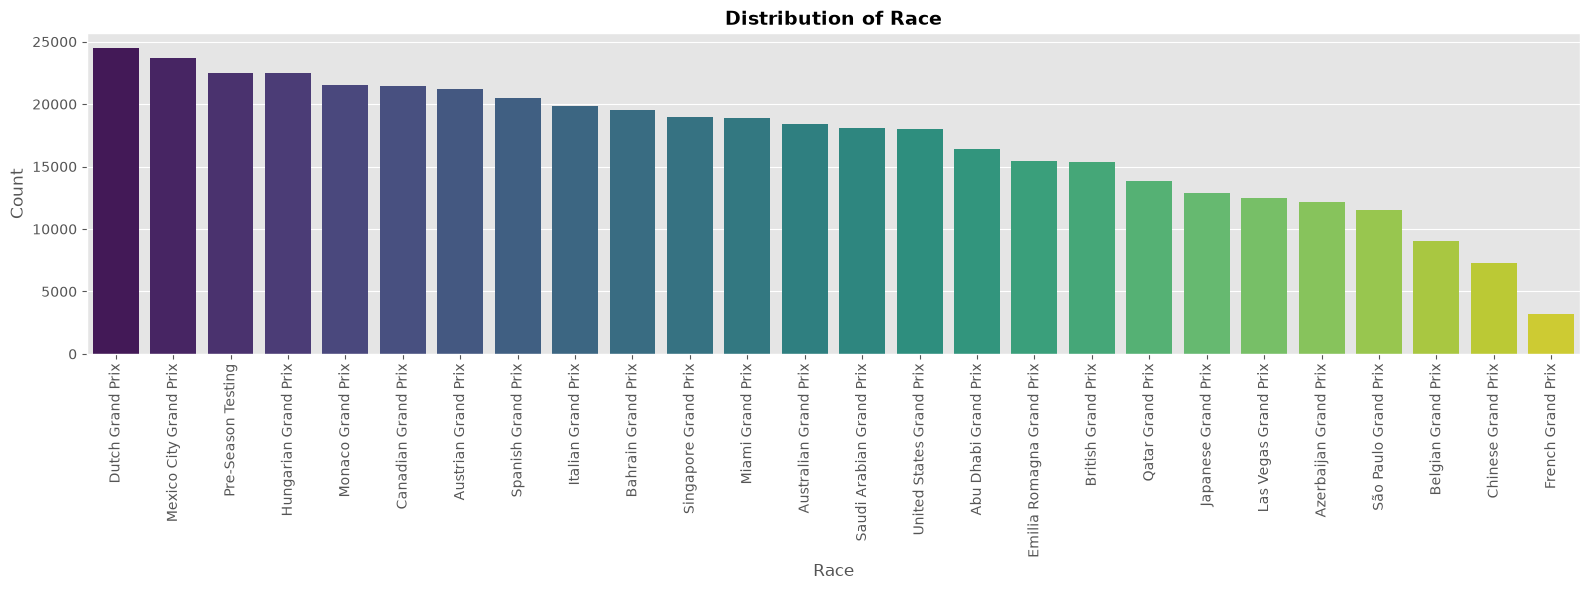


Most common: Dutch Grand Prix (5.6% of data)


In [15]:
# Comprehensive categorical feature analysis
for col in categorical_cols:
    print("\n" + "="*80)
    print(f"ANALYZING: {col}")
    print("="*80)
    
    value_counts = train_df[col].value_counts()
    print(f"\nUnique values: {len(value_counts)}")
    print("\nValue distribution:")
    print(value_counts)
    
    # Bar chart
    plt.figure(figsize=(16, 6))
    sns.countplot(
        data=train_df,
        x=col,
        order=train_df[col].value_counts().index,
        palette="viridis"
    )
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    # Balance assessment
    top_pct = (value_counts.iloc[0] / len(train_df)) * 100
    print(f"\nMost common: {value_counts.index[0]} ({top_pct:.1f}% of data)")

# ✅ Part 1 COMPLETE: Summary

## What We've Accomplished

### 📊 Data Exploration
- ✅ Loaded 3 datasets (train, test, sample submission)
- ✅ Analyzed dimensions and structure
- ✅ Verified data integrity

### 🔍 Quality Assessment
- ✅ Identified missing values
- ✅ Assessed data completeness
- ✅ Visualized data quality

### 📈 Feature Analysis
- ✅ Classified numerical vs categorical features
- ✅ Analyzed 10+ numerical features in depth
- ✅ Analyzed 3 categorical features in depth
- ✅ Studied feature distributions and characteristics

### 🏎️ Domain-Specific Insights
- ✅ Driver performance patterns
- ✅ Tyre compound effects
- ✅ Tyre degradation patterns
- ✅ Race progression dynamics
- ✅ Target variable analysis
- ✅ Feature correlations

## Key Findings
1. **Data Quality**: [From analysis above]
2. **Feature Patterns**: Identified domain-specific patterns affecting pit stops
3. **Class Balance**: Assessed balance of pit stop events
4. **Feature Relationships**: Understood correlations between variables

## Next: Part 2 - Feature Engineering
Now that we understand our data, we'll:
- Encode categorical variables
- Prepare features for modeling
- Create train/validation splits

---

**EDA is the foundation of successful ML modeling! 🎯**